# PCA(Principal Component Analysis, 주성분 분석)

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 데이터셋

In [8]:
# !wget https://bit.ly/fruits_300_data -0 fruits.npy
!wget https://bit.ly/fruits_300_data -O fruits.npy#대문자 O

--2026-02-05 01:24:29--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-02-05 01:24:30--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-02-05 01:24:30--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [11]:
fruits =np.load('fruits.npy#대문자')


In [12]:
fruits.shape

(300, 100, 100)

In [14]:
def plot_img_array(arr, ncols=10):
  # arr:(n_samples, heigth,width) 모양의 3차원 배열
  n=len(arr) # 배열의 아이템 개수(이미지 배열 개수)
  nrows= int(np.ceil(n/ncols)) # 배열인덱스는 항상정수int float는 불가
  # figsize=(figure_width, figure_height)
  fig,axes=plt.subplots(nrows,ncols,figsize=(ncols,nrows))
  for i in range(nrows):
    for j in range(ncols):
      idx= i*ncols+j #(i=0,j=10 [0,1...])
      if nrows ==1: # axes는 1차원 배열
        if idx < n:
          axes[idx].imshow(arr[idx],cmap=plt.cm.binary)
        axes[idx].axis('off')
      else: # axes는 2차원 배열
        if idx < n:
          axes[i,j].imshow(arr[idx],cmap=plt.cm.binary)
        axes[i,j].axis('off')
  plt.show()

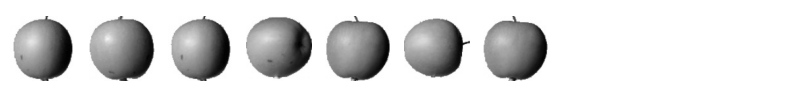

In [16]:
plot_img_array(fruits[:7])

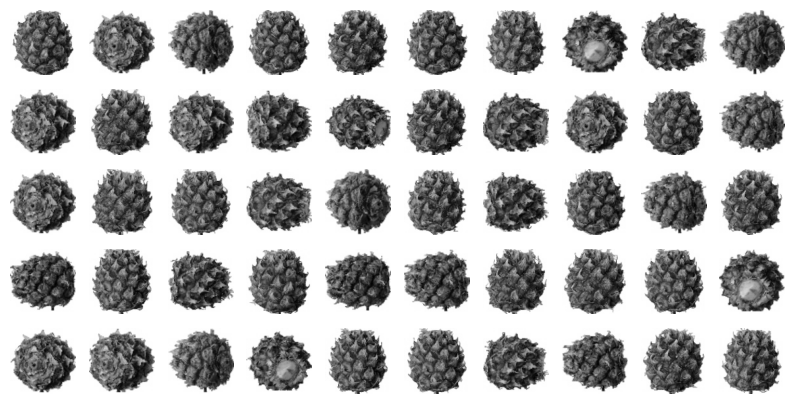

In [17]:
plot_img_array(fruits[100:150])

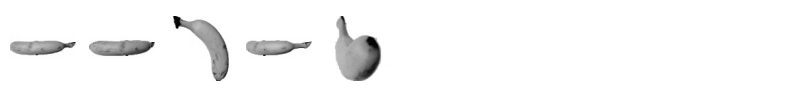

In [18]:
plot_img_array(fruits[200:205])

# PCA

* 데이터에서 분산이 최대가 되는 축을 찾음.
* 첫번째 축에서 수직(직교,othogonal)이면서 남은 분산이 최대가 되는 축을 찾음.
* 이전에 찾은 모든 축에 수직이면서 남은 분산이 최대가 되는 축을 찾음.
* 위의 과정 반복.
* 주성분 분석(PCA)를 사용해서 차원을 축소(압축)할 수 있음. 원래 차원으로 재구성할 수 있음.
  * 재구성 오차가 발생함.


In [19]:
# scikit-learn 클래스는 특성 배열로 2차원 배열을 사용.
fruits_2d =fruits.reshape((300,-1)) # 300, 10000

In [20]:
fruits_2d.shape

(300, 10000)

In [21]:
# PCA 객체 생성
pca =PCA(n_components=50,random_state=42) # 주 성분 백터를 50개로 설정.


In [22]:
# 모델 훈련(비지도 학습) > 50개의 주성분을 찾음
pca.fit(fruits_2d)

PCA(n_components=50, random_state=42)

In [24]:
# PCA가 찾은 50개의 주성분
pca.components_.shape # 50, 10000 > n_components, n_features

(50, 10000)

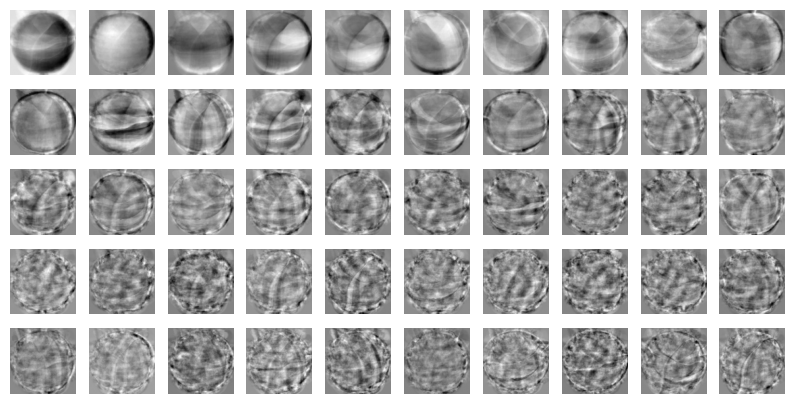

In [25]:
# PCA가 찾은 50개의 주성분 시각화
plot_img_array(pca.components_.reshape((50,100,100)))

## 차원 축소

`PCA.transform()` 메서드 호출.


In [26]:
# 차원축소: 300, 10000 >> 300, 50
fruits_2d_reduced=pca.transform(fruits_2d)

In [27]:
fruits_2d_reduced.shape

(300, 50)

## 차원 재구성

축소됐던 차원을 원래대로 되돌림. `PCA.inverse_transform()` 매서드 호출.

In [28]:
# 차원 재구성:(300, 50) > > (300, 10000)
reconstructed =pca.inverse_transform(fruits_2d_reduced)

In [30]:
reconstructed.shape

(300, 10000)

원본 과일 이미지와 차원 축소 후 재구성된 이미지 비교

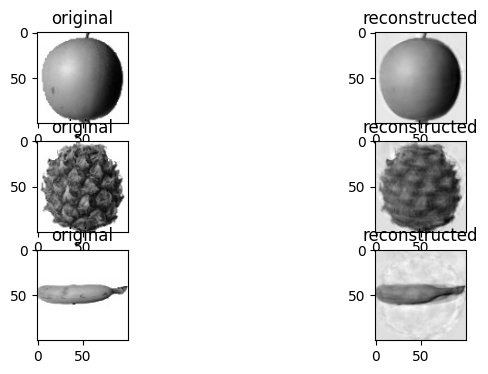

In [36]:
fig,axes=plt.subplots(nrows=3,ncols=2,figsize=(8,4))
# 원본이미지 시각화
axes[0][0].imshow(fruits[0],cmap=plt.cm.binary)

axes[0][0].set_title('original')
axes[1][0].imshow(fruits[100],cmap=plt.cm.binary)

axes[1][0].set_title('original')
axes[2][0].imshow(fruits[200],cmap=plt.cm.binary)

axes[2][0].set_title('original')

# 재구성된 이미지
axes[0][1].imshow(reconstructed[0].reshape((100,100)),cmap=plt.cm.binary)
axes[0][1].set_title('reconstructed')
axes[1][1].imshow(reconstructed[100].reshape((100,100)),cmap=plt.cm.binary)
axes[1][1].set_title('reconstructed')
axes[2][1].imshow(reconstructed[200].reshape((100,100)),cmap=plt.cm.binary)
axes[2][1].set_title('reconstructed')


plt.show()

## 설명된 분산 비율(Explained Variance Ratio)

데이터셋의 분산이 각 주성분 축에 따라 놓여 있는 비율

In [37]:
pca.explained_variance_ # 설명된 분산

array([13825250.21582   ,  3244970.17261193,  2147002.11072804,
        1315766.76701664,  1115261.57182812,  1071019.42512441,
         839909.3351522 ,   670735.97206957,   447908.41090739,
         438278.50206895,   376058.33742495,   308314.26930361,
         286653.1247086 ,   276360.41324009,   226209.88296423,
         210588.11319902,   188950.25665911,   166854.81151665,
         158753.89250673,   156784.14766241,   146172.9076885 ,
         142739.15925164,   133183.8073018 ,   127118.51886608,
         121563.9978921 ,   117267.70755638,   108186.69143077,
         103713.31379143,    99261.91052115,    99135.70605002,
          94228.05385711,    90040.30447215,    86470.73077457,
          83465.17255061,    82295.02646471,    80663.90690084,
          78094.08591389,    75280.88252636,    72420.27941843,
          70737.72071461,    69455.75778694,    63067.95163101,
          62874.74546014,    62293.2008208 ,    59670.32106508,
          59000.95658326,    55741.88321

In [38]:
pca.explained_variance_ratio_ # 설명된 분산 비율

array([0.42357017, 0.09941755, 0.06577863, 0.04031172, 0.03416875,
       0.03281329, 0.02573267, 0.02054963, 0.01372276, 0.01342773,
       0.01152146, 0.00944596, 0.00878232, 0.00846697, 0.00693049,
       0.00645188, 0.00578895, 0.005112  , 0.00486381, 0.00480346,
       0.00447836, 0.00437316, 0.00408041, 0.00389459, 0.00372441,
       0.00359278, 0.00331456, 0.00317751, 0.00304113, 0.00303726,
       0.00288691, 0.0027586 , 0.00264924, 0.00255716, 0.00252131,
       0.00247134, 0.0023926 , 0.00230641, 0.00221877, 0.00216722,
       0.00212795, 0.00193224, 0.00192632, 0.0019085 , 0.00182815,
       0.00180764, 0.00170779, 0.00166414, 0.00162624, 0.00156195])

In [40]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.9213948508475203)

In [41]:
np.cumsum(pca.explained_variance_ratio_) # 비율 누적 합계(cumulative summation)

array([0.42357017, 0.52298772, 0.58876636, 0.62907807, 0.66324682,
       0.69606011, 0.72179277, 0.7423424 , 0.75606517, 0.76949289,
       0.78101436, 0.79046031, 0.79924263, 0.8077096 , 0.81464009,
       0.82109197, 0.82688092, 0.83199293, 0.83685674, 0.8416602 ,
       0.84613856, 0.85051173, 0.85459213, 0.85848672, 0.86221113,
       0.86580391, 0.86911847, 0.87229598, 0.87533711, 0.87837438,
       0.88126128, 0.88401989, 0.88666913, 0.88922629, 0.89174759,
       0.89421893, 0.89661153, 0.89891794, 0.90113672, 0.90330394,
       0.90543188, 0.90736412, 0.90929044, 0.91119895, 0.91302709,
       0.91483473, 0.91654252, 0.91820666, 0.9198329 , 0.92139485])

설명된 분산 비율의 누적 합계를 선그래프로 시각화

In [42]:
x= np.arange(1,51)
y= np.cumsum(pca.explained_variance_ratio_)

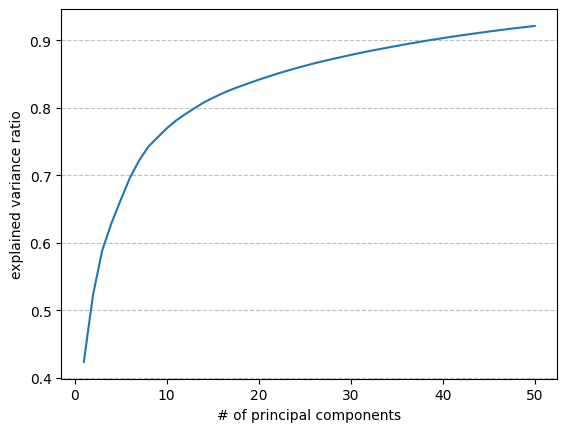

In [45]:
plt.plot(x,y)

plt.grid(
    axis='y',
    color='gray',
    linestyle='--',
    alpha=0.5
)
plt.xlabel('# of principal components')
plt.ylabel('explained variance ratio')
plt.show()

# 적절한 차원(주성분) 찾기

In [46]:
pca =PCA(random_state=42) # n_components= 설정안하면 전체범위
pca.fit(fruits_2d) # 모델 훈련 >> 주성분 찾기

PCA(random_state=42)

In [47]:
pca.components_.shape # PCA가 찾은 주성분 개수 =300

(300, 10000)

In [48]:
np.cumsum(pca.explained_variance_ratio_)

array([0.42357017, 0.52298772, 0.58876636, 0.62907807, 0.66324682,
       0.69606011, 0.72179277, 0.7423424 , 0.75606517, 0.76949289,
       0.78101436, 0.79046031, 0.79924263, 0.8077096 , 0.8146401 ,
       0.82109198, 0.82688094, 0.83199297, 0.83685681, 0.84166029,
       0.84613868, 0.85051188, 0.85459231, 0.85848713, 0.86221162,
       0.86580458, 0.86911941, 0.87229806, 0.87534166, 0.87837961,
       0.88126923, 0.88402859, 0.88667904, 0.88923903, 0.89176139,
       0.89423643, 0.89663418, 0.89894594, 0.90116987, 0.9033414 ,
       0.90548427, 0.90745515, 0.90939093, 0.91130807, 0.91316887,
       0.91500664, 0.91675557, 0.91846364, 0.92011235, 0.92174996,
       0.92335562, 0.92485381, 0.9263132 , 0.92771878, 0.92909083,
       0.93043373, 0.93175006, 0.93305409, 0.93432339, 0.93557371,
       0.93679504, 0.93800766, 0.93916379, 0.94030712, 0.94142862,
       0.94250822, 0.94358313, 0.94461596, 0.94562711, 0.94661251,
       0.94757512, 0.94850655, 0.94942598, 0.95033187, 0.95121

In [49]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.9999999999999998)

In [50]:
# 설명된 분산 비율 누적합계 시각화
x= np.arange(1, 301)
y= np.cumsum(pca.explained_variance_ratio_)

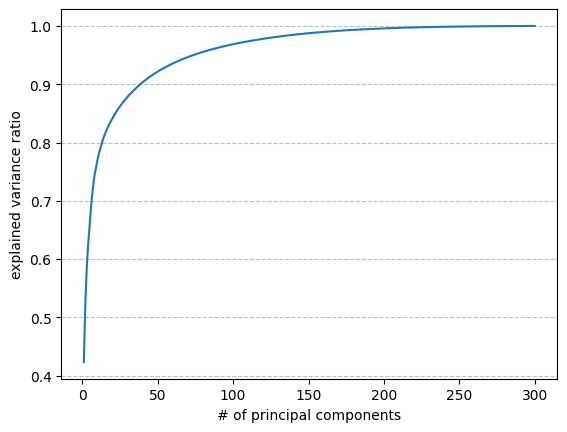

In [51]:
plt.plot(x,y)
plt.grid(
    axis='y',
    color='gray',
    linestyle='--',
    alpha=0.5
)
plt.xlabel('# of principal components')
plt.ylabel('explained variance ratio')
plt.show()

PCA 객체를 생성할 때 n_components 파라미터를 설명된 분산비율(0.0 ~ 1.0)로 설정할 수도 있음.

In [52]:
#  95% 설명된 분산 비율을 갖는 주성분 찾기
pca= PCA(n_components=0.95, random_state=42)
pca.fit(fruits_2d)

PCA(n_components=0.95, random_state=42)

In [53]:
pca.components_.shape # PCA가 찾은 95% 설명분산비율의 주성분 개수는 74개다

(74, 10000)

In [54]:
reduced=pca.transform(fruits_2d) # 차원 축소
reduced.shape

(300, 74)

In [55]:
reconstructed=pca.inverse_transform(reduced) # 차원 재구성
reconstructed.shape

(300, 10000)

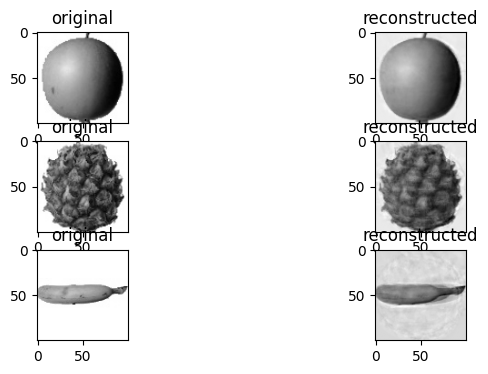

In [57]:
fig,axes=plt.subplots(nrows=3,ncols=2,figsize=(8,4))
# 원본이미지 시각화
axes[0][0].imshow(fruits[0],cmap=plt.cm.binary)

axes[0][0].set_title('original')
axes[1][0].imshow(fruits[100],cmap=plt.cm.binary)

axes[1][0].set_title('original')
axes[2][0].imshow(fruits[200],cmap=plt.cm.binary)

axes[2][0].set_title('original')

# 재구성된 이미지
axes[0][1].imshow(reconstructed[0].reshape((100,100)),cmap=plt.cm.binary)
axes[0][1].set_title('reconstructed')
axes[1][1].imshow(reconstructed[100].reshape((100,100)),cmap=plt.cm.binary)
axes[1][1].set_title('reconstructed')
axes[2][1].imshow(reconstructed[200].reshape((100,100)),cmap=plt.cm.binary)
axes[2][1].set_title('reconstructed')


plt.show()

# PCA와 지도학습(분류)

## 차원 축소 없이 분류

In [58]:
fruits_2d.shape

(300, 10000)

In [59]:
target= np.array([0]*100 + [1]*100 + [2]*100)

In [60]:
from sklearn.model_selection import cross_validate

In [61]:
# LogisticRegression 사용한 분류 모델 훈련/평가 시간 측정
%%time
cv =cross_validate(LogisticRegression(random_state=42,n_jobs=-1),
                   fruits_2d,target,
                   return_train_score=True)

CPU times: user 648 ms, sys: 223 ms, total: 872 ms
Wall time: 14.3 s


In [62]:
print('train score:',np.mean(cv['train_score']))
print('test score:',np.mean(cv['test_score']))

train score: 1.0
test score: 0.9966666666666667


## PCA를 사용해서 차원 축소 후 분류

In [63]:
pca =PCA(n_components=0.95,random_state=42) # PCA 객체 생성
pca.fit(fruits_2d) # 주성분 분석 실행

PCA(n_components=0.95, random_state=42)

In [64]:
reduced=pca.transform(fruits_2d) # 주성분을 이용한 차원 축소

In [65]:
reduced.shape # 300,74

(300, 74)

In [67]:
# 차원 축소된 데이터를 사용한 분류
%%time
cv=cross_validate(LogisticRegression(random_state=42,n_jobs=-1),
                  reduced,target,
                  return_train_score=True)

CPU times: user 74 ms, sys: 8.26 ms, total: 82.3 ms
Wall time: 5.72 s


In [68]:
print('train score:',np.mean(cv['train_score']))
print('test score:',np.mean(cv['test_score']))

train score: 1.0
test score: 0.9933333333333334


# PCA를 사용해서 차원 축소 후 가장 주된 2개의 주 성분 축 시각화

In [69]:
reduced.shape

(300, 74)

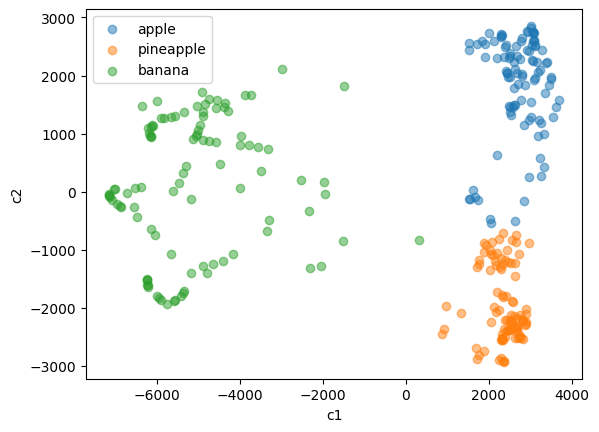

In [70]:
labels=['apple','pineapple','banana']
for i, lbl in enumerate(labels):
  plt.scatter(reduced[i*100:(i+1)*100,0], # 0= 0:100,0 1= 100:200,0
              reduced[i*100:(i+1)*100,1], # 0= 0:100,1 1= 100:200,1 0,1 axis
              label=lbl,
              alpha=0.5)
plt.legend()
plt.xlabel('c1')
plt.ylabel('c2')
plt.show()

**TODO** SVC

* 차원축소전, 훈련/평가 시간, 정확도
* 차원축소후, 훈련/평가 시간, 정확도

# MNIST 데이터셋

In [71]:
mnist= datasets.fetch_openml(name='mnist_784',as_frame=False)

In [72]:
x= mnist.data
y= mnist.target

In [73]:
x.shape

(70000, 784)

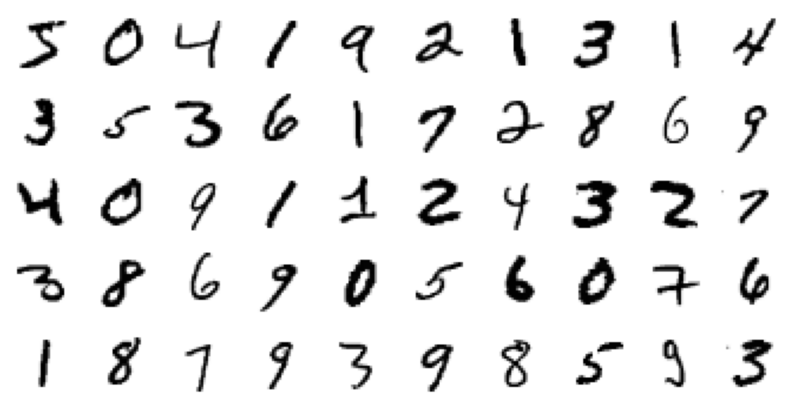

In [74]:
plot_img_array(x[:50].reshape((-1,28,28)))

In [75]:
28*28

784

## 차원 축소 없는 경우

In [76]:
%%time
cv=cross_validate(LogisticRegression(random_state=42,n_jobs=-1),
                  x,y,
                  return_train_score=True)

CPU times: user 6.26 s, sys: 2.34 s, total: 8.6 s
Wall time: 2min 46s


In [77]:
print('train score:',np.mean(cv['train_score']))
print('test score:',np.mean(cv['test_score']))

train score: 0.9350821428571429
test score: 0.9200857142857142


## 차원 축소 했을 때

In [78]:
pca=PCA(n_components=0.95,random_state=42) # PCA 객체 생성

In [80]:
pca.fit(x) # 주성분 분석

PCA(n_components=0.95, random_state=42)

In [81]:
reduced=pca.transform(x)

In [82]:
classes = mnist.categories['class']

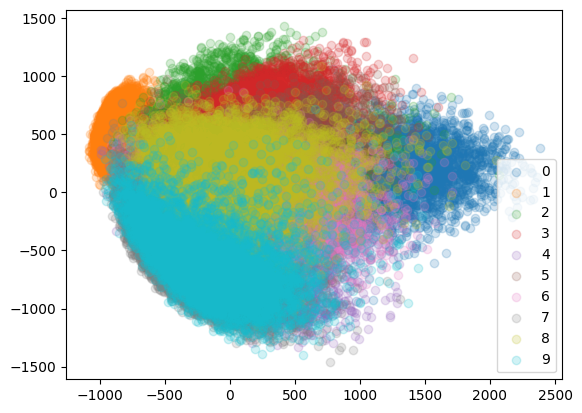

In [83]:
for i, cls in enumerate(classes):
  plt.scatter(reduced[y == cls, 0],
              reduced[y == cls, 1],
              label=cls,alpha=0.2)

plt.legend()
plt.show()


In [84]:
%%time
cv=cross_validate(LogisticRegression(random_state=42,n_jobs=-1),
                  reduced, y, return_train_score=True)


CPU times: user 2.92 s, sys: 308 ms, total: 3.23 s
Wall time: 59.3 s


In [85]:
print('train score:',np.mean(cv['train_score']))
print('test score:',np.mean(cv['test_score']))

train score: 0.9226142857142857
test score: 0.9150142857142857
